In [1]:
# Zomato Data Analysis Project

In [ ]:
##Step 1 - Importing Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
palette_color=sns.color_palette('bright')

In [ ]:
#Step 2-Creating dataframe


In [2]:
dataframe=pd.read_csv("Zomato data .csv")

In [4]:
print(dataframe.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [5]:
dataframe.columns.values

array(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'], dtype=object)

In [5]:
#Converting the data type of column rate

In [3]:
def newRate(value):
    value=str(value).split('/')
    value=value[0]
    return float(value)

dataframe['rate']=dataframe['rate'].apply(newRate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [7]:
 dataframe.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [8]:
#Visualizing the count of order by type of restaurant

Text(0.5, 0, 'type of restaurant')

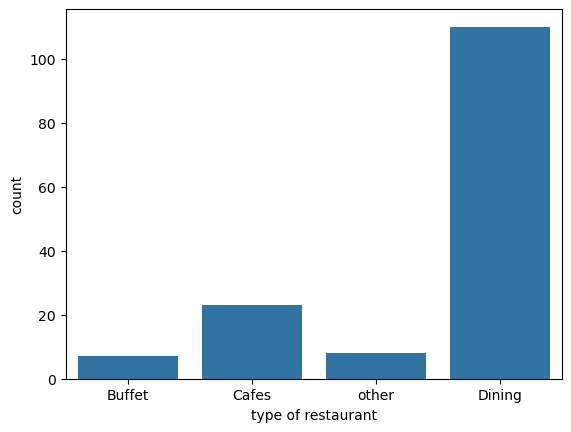

In [17]:

sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel("type of restaurant" )

In [10]:
#conclusion the majority of restaurant falls in dining category

In [11]:
#Q2- finding the votes grouped by category of restaurant

Text(0, 0.5, 'Votes')

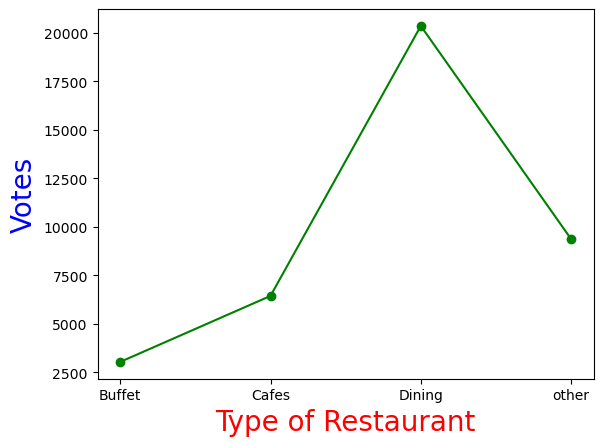

In [17]:
grouped_data=dataframe.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes':grouped_data})
plt.plot(result,c="green",marker="o")
plt.xlabel("Type of Restaurant", c="red", size=20)
plt.ylabel("Votes", c="blue", size=20)


<Axes: xlabel='online_order', ylabel='count'>

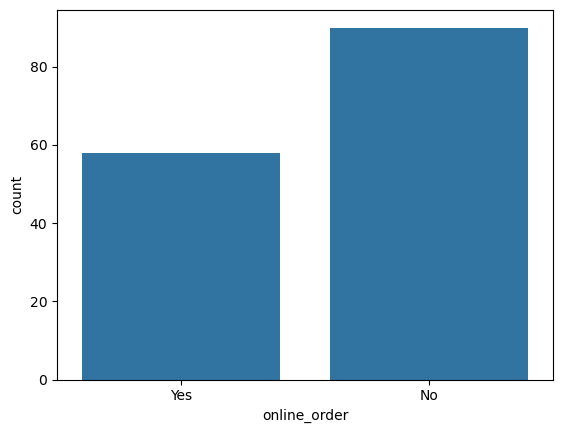

In [5]:
sns.countplot(x=dataframe['online_order'])

In [ ]:
# Conclusion: This suggests that a majority of the restaurants do not accept online orders.

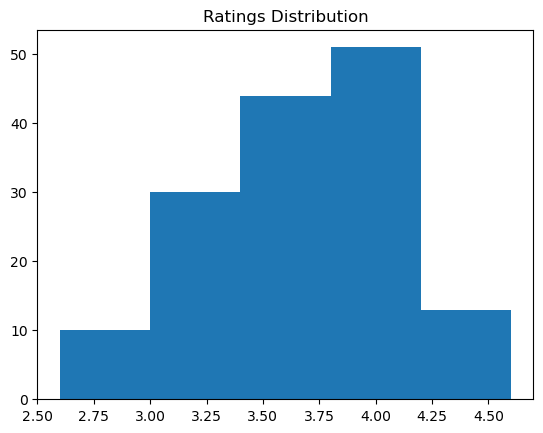

In [6]:
plt.hist(dataframe['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

In [ ]:
# Conclusion: The majority of restaurants received ratings ranging from 3.5 to 4.

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

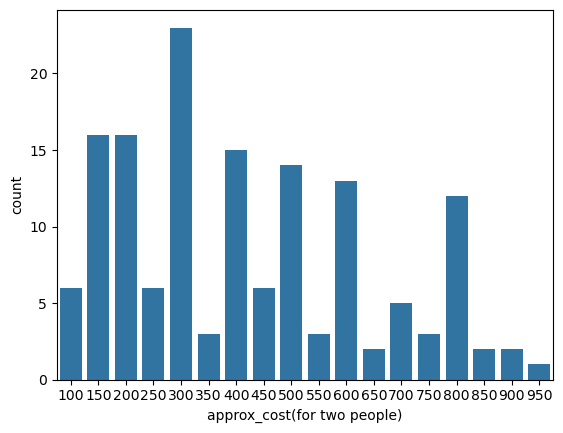

In [7]:
couple_data=dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)


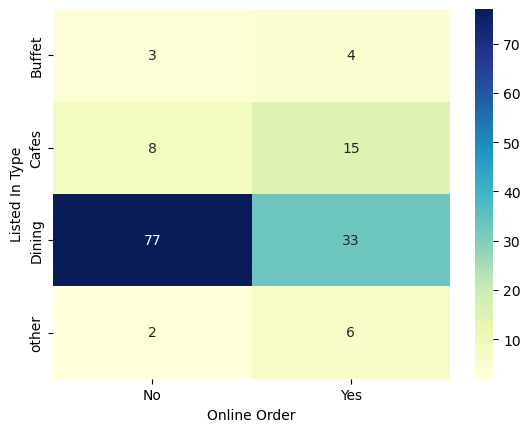

In [21]:
pivot_table=dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt="d")
plt.xlabel("Online Order")
plt.ylabel("Listed In Type")
plt.show()
